In [3]:
!git clone https://github.com/stiflet/CandidateProject.git
!hf download Stiflet/WeatherData --repo-type=dataset --local-dir=Weather_Models
%pip install ondil ngboost
%cd CandidateProject

Cloning into 'CandidateProject'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 67 (delta 18), reused 47 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 4.85 MiB | 15.05 MiB/s, done.
Resolving deltas: 100% (18/18), done.
Fetching 9 files: 100%|███████████████████████████| 9/9 [00:01<00:00,  4.68it/s]
Download complete: : 199MB [00:01, 141MB/s]                                     /kaggle/working/CandidateProject/Weather_Models
Download complete: : 199MB [00:01, 102MB/s]
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 11.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.3 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=1bac41d89e4630495bc

# Introduction

The purpose of the project is to test a threshold based classifier approach for probabilistic temperature forecasting. Instead of predicting only a single temperature value, the goal is to estimate the full predictive distribution of the observed temperature.

Normally, probabilistic weather forecasting is often done using ensemble forecasts, where multiple forecast members provide information about uncertainty. However, in this project i will be using deterministic HRRR forecasts instead. This makes the problem more challenging, because HRRR does not directly provide an ensemble mean or ensemble spread. Therefore, the model has to learn forecast uncertainty from historical forecast errors and the available weather predictors.

The method is tested on HRRR forecasts for KLGA, matched with METAR temperature observations. The forecast features include variables such as 2 metre temperature, dew point, relative humidity, wind components, cloud cover, lead time, calendar features, and observed temperature information available at model run time ect. I also add bias corrected forecast features from a distributional regression model, so the classifier has access to both a corrected forecast mean and an estimated forecast scale.

Instead of only forecasting temperature at a single lead time, the data cleaning process transforms the data into a maximum temperature forecasting problem. For each model run, the forecast row with the highest predicted temperature is selected, and the target becomes the observed maximum temperature over the same forecast window. This makes the experiment more realistic and slightly more difficult than predicting one fixed lead time.

Different models are then tested for the threshold based CDF estimator, including logistic regression, XGBoost, and planning on testing a neural network in Keras. The models are evaluated using probabilistic verification metrics such as the Brier score, CRPS, and PIT histograms. 

The overall goal is to investigate whether a classifier based CDF model can learn a useful and calibrated predictive distribution from deterministic HRRR forecast features. If it works, it might suggests that HRRR forecasts can still be used for probabilistic post processing, without ensemble information.

# Fetching data

My original idea was to use ensemble forecasts for this project, since ensemble forecasting is the standard approach when modelling forecast uncertainty.

However, I found that fetching a large enough ensemble dataset was very difficult. I was able to gather around 2000 rows from the dynamical.org GEFS Zarr archive (https://dynamical.org/catalog/noaa-gefs-forecast-35-day/), containing one model run per day. While this dataset was useful for testing the EMOS framework, (there is a notebook for this on GitHub), I considered it too small for properly testing the threshold based CDF setup. 

Because of this, I decided to use the HRRR model instead. HRRR is a deterministic numerical weather prediction model, meaning that it does not provide an ensemble distribution directly. However, it also has some practical advantages compared with the Global Ensemble Forecast System (GEFS).

The HRRR model runs every hour with hourly lead times, whereas the GEFS data is much less frequent. Dynamical.org only provided one GEFS model run per day, and it was the only usable GEFS Zarr library I could find. Downloading the GRIB files directly from the official AWS archive was not really feasible. Because HRRR is available much more frequently, it made it possible to collect a substantially larger dataset than I could with GEFS.

Another advantage is that HRRR has a spatial resolution of approximately 3 km, compared with around 25 km for GEFS. This means that HRRR can capture more localized weather patterns. This does not automatically mean that HRRR is always more accurate, but it makes the model more useful where locally.

However, using HRRR instead of GEFS also has some clear downsides, especially when the goal is to model uncertainty. Since the raw HRRR forecast is deterministic, it does not contain ensemble spread or an ensemble mean. Therefore, the probabilistic model has to learn uncertainty only from the historical forecast variables it is given, rather than from direct information about forecast spread.

This makes the setup more challenging, but also more interesting. The goal is to investigate whether a model can learn a calibrated predictive distribution using only deterministic forecast features.

For each forecast case, I used HRRR variables such as 2 metre temperature above ground, dew point, relative humidity, wind components, cloud cover, and lead time as predictors. These variables were then matched with the corresponding observed temperature.


# Threshold based CDF estimation model

The model I want to test is a probabilistic forecasting method for estimating the full predictive distribution of a continuous variable. Instead of assuming a specific distribution, such as a Gaussian distribution in EMOS or Gaussian distributional regression, the model estimates the cumulative distribution function directly.

## Overview

The main idea is to convert the continuous forecasting problem into a set of binary classification problems. For a large set of temperature thresholds, the model learns the probability that the observed temperature will be less than or equal to each threshold.

So instead of predicting only a single temperature value, the model predicts probabilities of the form


$$P(\text{Observed Temperature} \leq \text{Temperature Threshold})$$

for many different threshold values.

By predicting these probabilities across a grid of thresholds, the model produces an estimated cumulative distribution function. This CDF can then be used as a full probabilistic forecast.

## Mathematical definition

Let


$$Y_i = \text{observed temperature for forecast case i}$$


$$x_i = \text{NWP forecast predictors for forecast case i}$$

and


$$t_1, t_2, \dots, t_K$$

be a fixed grid of thresholds covering the relevant range of the target variable.

For each original forecast case, the data is expanded by repeating the case once for every threshold. So If the original dataset contains $N$ forecast cases and we choose $K = 100$ thresholds, the expanded dataset contains $100N$ rows.

The classifier is then trained to estimate


$$\hat{F}(t_k \mid x_i) = P(Y_i \leq t_k \mid x_i)$$

where $\hat{F}(t_k \mid x_i)$ is the predicted probability at threshold $t_k$.

## Predictive distribution

After training, the model produces estimated probabilities


$$\hat{F}(t_1 \mid x_i), \hat{F}(t_2 \mid x_i), \dots, \hat{F}(t_K \mid x_i)$$


for each forecast case $i$.

These values form an estimated cumulative distribution function over the chosen temperature thresholds. The resulting forecast is therefore not a single temperature value, but a full predictive distribution.


## More flexibility

In EMOS or distributional regression, the preictive distribution is usually specified through a chosen distribution. The model then learns the mean and standard deviation for each forecast case.

In contrast, the threshold based CDF model does not require choosing a parametric distribution. Instead, it learns the CDF values directly at a set of thresholds.

This makes the method more flexible because the shape of the predictive distribution is learned from data rather than specified beforehand. 

## Monotonicity

Because a valid CDF cannot be decreasing, the predicted probabilities should satisfy

$$\hat{F}(t_1 \mid x_i) \leq \hat{F}(t_2 \mid x_i) \leq \dots \leq \hat{F}(t_K \mid x_i)$$


for increasing thresholds


$$t_1 < t_2 < \dots < t_K$$


In practice, monotonicity can be enforced in the model if it allows it, or after prediction by applying numpy.maximum.accumulate on the CDF.



# Evaluation Metrics


## Brier Score

The Brier score is used to evaluate the probabilities produced at each individual threshold. The Brier score then measures the squared difference between the predicted probability and the binary true outcome.

### Mathematical definition

For a single temperatur threshold $t_k$, the model predicts the conditional probability that the observed temperature is less than or equal to that threshold, given the NWP forecast predictors:

$$
\hat{F}_i(t_k) = P(T_i \leq t_k \mid x_i)
$$

where $T_i$ is the temperature for forecast case $i$, and $x_i$ contains the input variables for forecast case i, such as the NWP forecast predictors.

Then the binary outcome for threshold $t_k$ is

$$
T_i \leq t_k\
$$

where

$$
T_i \leq t_k\ =
\begin{cases}
1, & \text{if } T_i \leq t_k \\
0, & \text{otherwise.}
\end{cases}
$$

For a single forecast case and a single threshold, the Brier score is simply the squared error between the predicted probability and the binary outcome:

$$
\left(
\mathbb{1}\{T_i \leq t_k\} - \hat{F}_i(t_k)
\right)^2
$$

Across one threshold $t_k$ over all forecast cases, the Brier score is written as the mean squared error:

$$
BS_k =
\frac{1}{n}
\sum_{i=1}^{n}
\left(
\hat{F}_i(t_k) - \mathbb{1}\{T_i \leq t_k\}
\right)^2
$$

where $n$ is the number of forecast cases.

Across all thresholds, the average Brier score is

$$
BS =
\frac{1}{nK}
\sum_{i=1}^{n}
\sum_{k=1}^{K}
\left(
\hat{F}_i(t_k) - \mathbb{1}\{T_i \leq t_k\}
\right)^2
$$

where $K$ is the number of thresholds.

# Continuous Ranked Probability Score

CRPS is used to evaluate the full predicted cumulative distribution function. It measures how close the predicted CDF is to the actual observed temperature.

For any threshold $t$, the observed CDF is 0 if the observed temperature is above the threshold, and 1 if the observed temperature is less than or equal to the threshold. CRPS compares the predicted probability from the model at each threshold with the observed binary outcome. It does this by measuring the total squared distance between the predicted CDF and the observed CDF. A smaller CRPS means that the predicted distribution is closer to the observed distribution.

## Mathematical definition

Let

$$
\hat{F}_i(t)
$$

be the predicted CDF for forecast case $i$ at threshold $t$.

Let

$$
T_i
$$

be the observed temperature at forecast caes i.

For an infinite amount of thresholds the CRPS is defined as
$$
CRPS_i =
\int_{-\infty}^{\infty}
\left(
\hat{F}_i(t) - T_i \leq t
\right)^2 dt
$$


However for the threshold based CDF estimator, the model is evaluated on a finite amount of thresholds

$$
t_1, t_2, \dots, t_K.
$$

Therefore, the CRPS is approximated over these thresholds:

$$
CRPS_i \approx
\int
\left(
\hat{F}_i(t_k) - T_i \leq t_k\
\right)^2 dt.
$$


The average CRPS over all n forecast cases is




$$
CRPS = \frac{1}{n}\sum_{i=1}^{n}CRPS_i
$$

# Continuous Ranked Probability Score

CRPS is used to evaluate the full predicted cumulative distribution function. It measures how close the predicted CDF is to the actual observed temperature.

For any threshold $t$, the observed CDF is 0 if the observed temperature is above the threshold, and 1 if the observed temperature is less than or equal to the threshold. CRPS compares the predicted probability from the model at each threshold with this observed binary outcome. It does this by measuring the total squared distance between the predicted CDF and the observed CDF. A smaller CRPS means that the predicted distribution is closer to the observed distribution.

## Mathematical definition

Let

$$
\hat{F}_i(t)
$$

be the predicted CDF for forecast case $i$ at threshold $t$.

Let

$$
T_i
$$

be the observed temperature for forecast case $i$.

For an infinite amount of thresholds, the CRPS is defined as

$$
CRPS_i =
\int_{-\infty}^{\infty}
\left(
\hat{F}_i(t) - \mathbb{1}\{T_i \leq t\}
\right)^2 dt
$$

However, for the threshold-based CDF estimator, the model is evaluated on a finite amount of thresholds

$$
t_1, t_2, \dots, t_K.
$$

Therefore, the CRPS is approximated over these thresholds:

$$
CRPS_i \approx
\sum_{k=1}^{K}
\left(
\hat{F}_i(t_k) - \mathbb{1}\{T_i \leq t_k\}
\right)^2 \Delta t
$$

The average CRPS over all $n$ forecast cases is

$$
CRPS = \frac{1}{n}\sum_{i=1}^{n}CRPS_i
$$

# Probability Integral Transform Histogram

The PIT histogram is used to evaluate the calibration of the predicted distribution.

## Overview

For each observation, the PIT value is found by evaluating the predicted CDF at the observed value:

$$
PIT_i = \hat{F}(T_i \mid x_i)
$$

In the threshold based CDF estimator setup, this is simply done by replacing the threshold feature with the observed value and then predicting the probability at that value.

If the predictive distributions are perfectly calibrated, the PIT values should be uniformly distributed between 0 and 1, e.g. a completely flat histogram.

## Mathematical definition

For observation $i$, the PIT value is

$$
u_i = \hat{F}(T_i \mid x_i)
$$

where

$$
u_i \in [0,1].
$$

A calibrated probabilistic forecast should satisfy

$$
u_i \sim Uniform(0,1).
$$

## Interpretation

A flat PIT histogram indicates good calibration.

A $\cup$ shaped PIT histogram usually means that the predictive distributions are too narrow. This means the observations fall too often in the tails of the predicted distributions.

A $\cap$ shaped PIT histogram usually means that the predictive distributions are too wide. This means the observations fall too often near the middle of the predicted distributions.




# Loading Libraries

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, brier_score_loss
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier
from ondil.estimators import OnlineDistributionalRegression
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.constants import convert_temperature
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline
from ngboost.scores import CRPScore
from ngboost import NGBRegressor
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import xgboost as xgb
import pandas as pd
import numpy as np
import optuna
import keras


2026-05-01 15:14:19.973347: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777648460.203044      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777648460.270462      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777648460.793633      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777648460.793672      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777648460.793675      57 computation_placer.cc:177] computation placer alr


# Functions

## Preprocessing

In [5]:
# Function for adding calendar features to the dataframe.
def add_calendar_features(df):

    # Season function
    def get_season(date):
        md = date.month * 100 + date.day
        if 321 <= md <= 620:
            return "spring"
        elif 621 <= md <= 922:
            return "summer"
        elif 923 <= md <= 1220:
            return "autumn"
        else:
            return "winter"

    idx = df.index
    df.copy()
    # Adding the new calendare features to the df.
    df['year']         = idx.year
    df['month']        = idx.month
    df['day']          = idx.day
    df['weekday']      = idx.weekday
    df['hour']         = idx.hour
    df['dayofyear']    = idx.dayofyear
    df['season']       = idx.to_series().apply(get_season)


    # Converting the categorical calendar features to float
    cat_cols = df.select_dtypes('object').columns
    for col in cat_cols:
        df[col] = df[col].astype('category').cat.codes.astype(float)
        
    return df

def create_df(forecasts: pd.DataFrame, observations: pd.DataFrame, lead_times: list):

    #Both observations and forecasts are gathered at timezone UTC
    forecasts.index = pd.to_datetime(forecasts.index, utc=True)

    # Align observations hourly
        # The observations are recorded at minute 51 and forecasts at 00, is this a problem? 
    observations.index = pd.to_datetime(observations.index, utc=True).ceil('h')

    # Join hourly observations to hourly forecast rows
    df = forecasts.join(observations)
    
    # Adding calendar features
    df = add_calendar_features(df)
    
    # Sorting the dates on the index
    df = df.reset_index().set_index(['run_time', 'valid_time']).sort_index()


    # Convert forecast temperatures
    df[['tmp_2m_c', 'dpt_2m_c']] = df[['tmp_2m_c', 'dpt_2m_c']].apply(convert_temperature, args=('k', 'f'))

    # Drop rows with missing values
    df = df.dropna(subset=["obs"]).reset_index(names=['run_time', "valid_time"])


    return df



def get_maxtemps(df: pd.DataFrame):

    # Row where the forecast predicts the highest temp for each run
    df_max_temps = df.loc[df.groupby('run_time')['tmp_2m_c'].idxmax()].copy()

    # Observed max over the same window for each run
    obs_max = df.groupby('run_time')['obs'].max().rename('obs_temp')

    # Merge observations and max temperatures
    df_max_temps = df_max_temps.merge(obs_max, on='run_time', how='left').drop('obs',axis = 1).rename({'obs_temp': 'obs'}, axis = 1)
    df_max_temps = df_max_temps.set_index("run_time").drop('valid_time', axis = 1)

    return df_max_temps


def repeat_df_static(df, thresholds):

    # Repeating each index value length of thresholds amount of times
    df_repeated = df.loc[df.index.repeat(len(thresholds))].copy()

    # Making the threshold column by tileing the threshold values over each repeated section
    df_repeated["threshold"] = np.tile(thresholds, len(df))

    # Creating a binary target
    df_repeated["target"] = (df_repeated['obs'] <= df_repeated["threshold"]).astype(int)

    return df_repeated

## Evaluation

In [6]:

def calculate_crps(preds, thresholds, y):
    # Making a matrix with the cdf function for every model run.
    cdf_matrix = preds.reshape(-1, len(thresholds))
    
    # Making a target matrix for the binary target observation for each model run.
    target_matrix = y.to_numpy().reshape(-1, len(thresholds))
    
    # Calculating CRPS.
    # Where np.trapezoid is the integral.
    crps = np.trapezoid((cdf_matrix - target_matrix)**2, thresholds, axis=1)
    
    return crps.mean()

# Data preprocessing

## Reading Data

In [7]:

# Reading forecasts to a pandas dataframe
forecasts = pd.read_parquet('/kaggle/working/Weather_Models/Forecasts/hrrr/klga.parquet').set_index('valid_time')

# Reading observations to a pandas dataframe
obs = pd.read_parquet('/kaggle/working/Weather_Models/Observations/metar_klga.parquet').set_index('valid').tmpf.rename('obs')

## Feature Engineering

In [8]:
lead_times = list(range(1,19))

# Setting the index to run time
df_og = create_df(forecasts, obs, lead_times).set_index('run_time').tz_localize('utc').copy()

# Merging observations available at model run time with the just created df
obs_runtime = obs.rename('obs_runtime').to_frame()

# Creating rolling stats over the past 10 hours
    # OBS use autocorrelation to choose the best lagged features
obs_runtime['obs_max'] = obs_runtime.obs_runtime.rolling('10h').max()
obs_runtime['obs_min'] = obs_runtime.obs_runtime.rolling('10h').min()
obs_runtime['obs_mean'] = obs_runtime.obs_runtime.rolling('10h').mean()

# Creating lagged observations
obs_runtime['obs_runtime_lag1'] = obs_runtime['obs_runtime'].shift(1)
obs_runtime['obs_runtime_lag2'] = obs_runtime['obs_runtime'].shift(2)
obs_runtime['obs_runtime_lag3'] = obs_runtime['obs_runtime'].shift(3)


# Joining the original df with the observations on the run time index
df_og = df_og.join(obs_runtime).dropna().reset_index(names = 'run_time').dropna()

# Creating a df with the forecasted maximum temperature and corresponding observed maximum per model run
df_max = get_maxtemps(df_og)

df_max.head()

,lead_hour,tmp_2m_c,dpt_2m_c,rh_2m,u10,v10,tcdc,year,month,day,...,dayofyear,season,obs_runtime,obs_max,obs_min,obs_mean,obs_runtime_lag1,obs_runtime_lag2,obs_runtime_lag3,obs
run_time,,,,,,,,,,,,,,,,,,,,,
2020-01-01 04:00:00+00:00,13,38.930012,29.930012,70.8750,5.578125,1.658203,0.0,2020,1,1,...,1,3.0,42.0,45.0,42.0,43.500000,43.0,44.0,45.0,42.0
2020-01-01 05:00:00+00:00,12,39.380013,30.380011,71.3125,5.511719,1.471680,0.0,2020,1,1,...,1,3.0,42.0,45.0,42.0,43.200000,42.0,43.0,44.0,42.0
2020-01-01 06:00:00+00:00,11,39.380013,30.380011,71.0000,5.523438,1.377930,0.0,2020,1,1,...,1,3.0,40.0,45.0,40.0,42.666667,42.0,42.0,43.0,40.0
2020-01-01 07:00:00+00:00,10,39.830009,30.380011,70.6250,5.605469,1.045898,0.0,2020,1,1,...,1,3.0,40.0,45.0,40.0,42.285714,40.0,42.0,42.0,40.0
2020-01-01 08:00:00+00:00,9,39.830009,30.830011,71.1250,5.312500,1.484375,0.0,2020,1,1,...,1,3.0,40.0,45.0,40.0,42.000000,40.0,40.0,42.0,40.0


In [9]:
# Turn cyclical features into sin/cos so the model understands they wrap around
# e.g. hour 23 is close to hour 0, not far away like raw numbers suggest.
# This helps the model learn smoother patterns over time.

df_max['dayofyear_sin'] = np.sin(2 * np.pi * df_max['dayofyear'] / 365)
df_max['dayofyear_cos'] = np.cos(2 * np.pi * df_max['dayofyear'] / 365)

df_max['hour_sin'] = np.sin(2 * np.pi * df_max['hour'] / 24)
df_max['hour_cos'] = np.cos(2 * np.pi * df_max['hour'] / 24)


df_max['lead_hour_sin'] = np.sin(2 * np.pi * df_max['lead_hour'] / 24)
df_max['lead_hour_cos'] = np.cos(2 * np.pi * df_max['lead_hour'] / 24)


df_max = df_max.drop(['dayofyear', 'hour', 'lead_hour'], axis = 1)

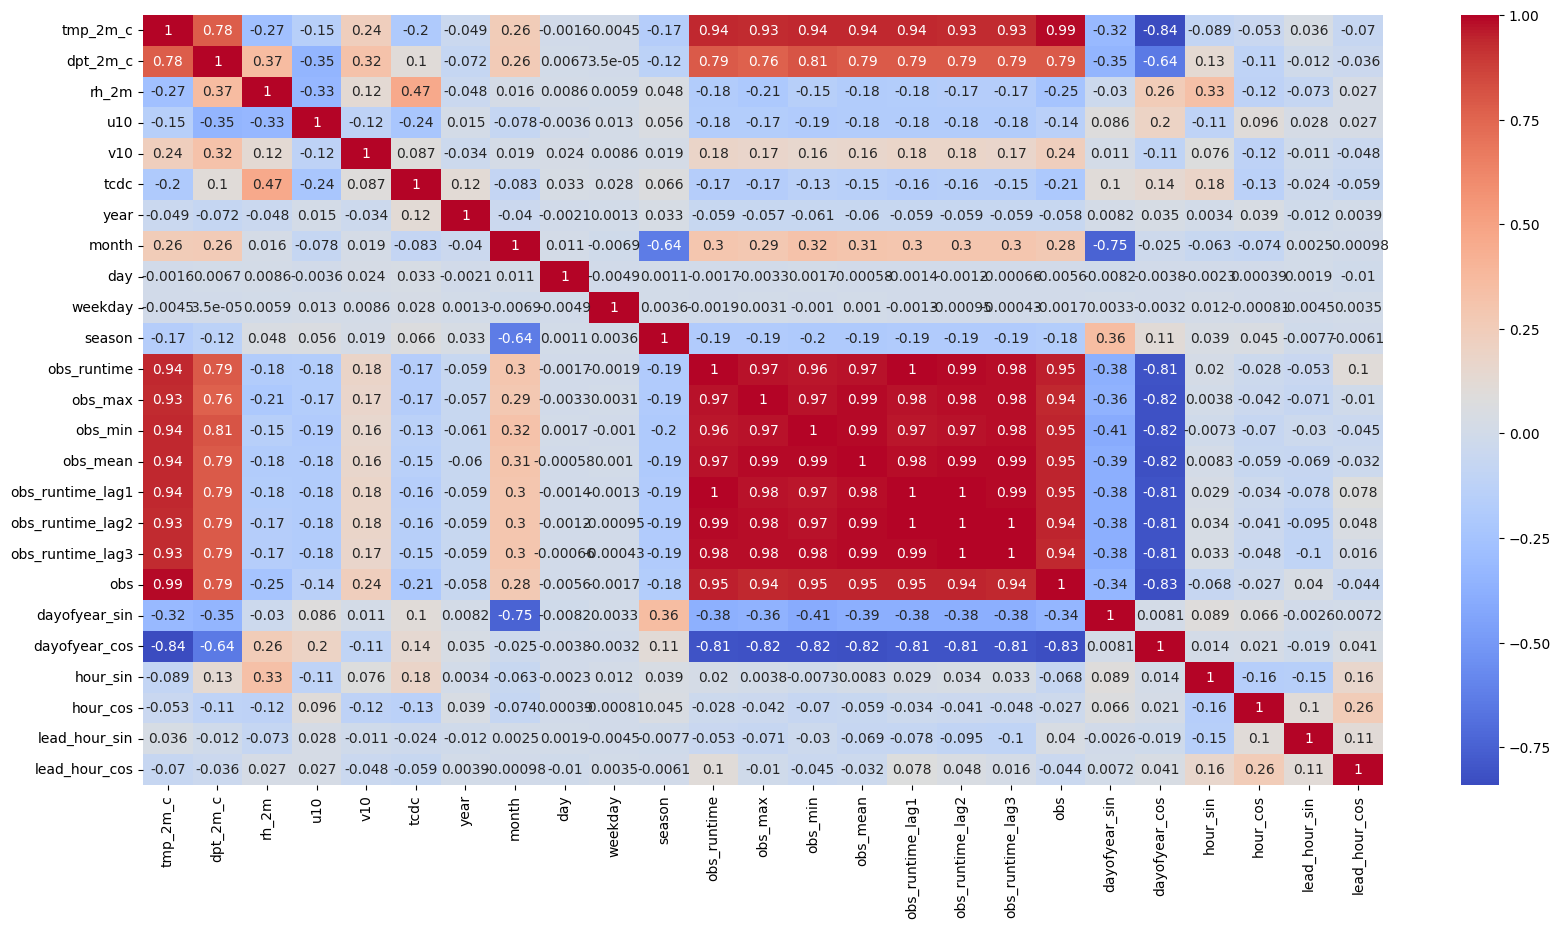

In [10]:
# Plotting a very confusing correlation matrix
corr = df_max.corr('spearman')

plt.figure(figsize=(20, 10))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.savefig('correlation.png')

In [11]:
# Making a quick feature selection using XGBoost to also capture non linear relationships


X_features_selection = df_max.drop('obs', axis=1)
y_features_selection = df_max['obs']


# Using only 20% of the data as training data for the feature selection and distributional regressor, to keep as much data as possible for the main model.
# Shuffle is set to False, to avoid any data leakage.
X_train, X_test, y_train, y_test = train_test_split(X_features_selection, y_features_selection, train_size=0.2, shuffle=False)


# This model is only used for feature selection, not as the final forecasting model.
xgb_model = xgb.XGBRegressor(
    random_state=42,
    device='cuda'
)

xgb_model.fit(X_train, y_train)


result = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    scoring='neg_mean_squared_error',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    result.importances_mean,
    index=X_train.columns
).sort_values(ascending=False)


# Selecting features with an importance above 0.
    # OBS: THIS IS VERY SIMPLE AND PROBABLY HAS TO BE REFINED
selected_features = importance[importance > 0].index
selected_features

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [15:14:46] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [15:14:49] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the devic

Index(['tmp_2m_c', 'obs_runtime', 'dpt_2m_c', 'dayofyear_cos', 'lead_hour_sin',
       'dayofyear_sin', 'u10', 'tcdc', 'hour_cos', 'obs_runtime_lag3', 'v10',
       'rh_2m', 'obs_mean', 'lead_hour_cos', 'weekday', 'obs_runtime_lag2',
       'hour_sin'],
      dtype='object')

In [13]:
from ondil.distributions import Normal

# Creating bias corrected temperature forecast and scale features


# The features from the feature selection is chosen and the data is split like above
bias_correct, df_main = train_test_split(df_max[selected_features.tolist() + ['obs']], train_size = 0.2, shuffle = False)



X_bias = bias_correct.drop('obs', axis = 1)
y_bias = bias_correct.obs

equation = {
    0: 'all', # Mean
    1: 'all', # Scale
}

# Create the estimator
# The online infront of the regressor, is because the library can be used to add more data to the model whenever it gets available.
# Besides that it is just a normal distributional regression.
model = OnlineDistributionalRegression(
    distribution=Normal(),
    method='ols',
    equation=equation,
    fit_intercept=True,
    ic='bic',
)

model.fit(X_bias, y_bias)

# Adding the predicted features to the rest of the data
df_main[['forecast_mean', 'forecast_scale']] = model.predict_distribution_parameters(df_main.drop('obs', axis = 1))




MAE Raw Forecast:  2.088549895648878
MSE Raw Forecast:  7.412358269939502
MAE Bias Corrected Forecast:  1.6182186150846245
MSE Bias Corrected Forecast:  4.620673680793204


<Axes: ylabel='Density'>

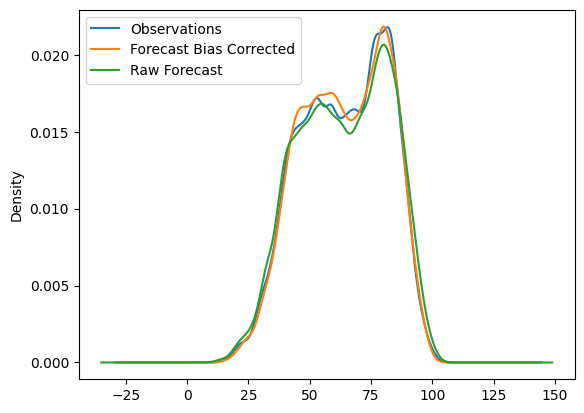

In [14]:
# Plotting distributions to see if the bias correct forecast mean from above has improved the raw NWP forecast


distributions = pd.DataFrame({
    'Observations': df_main.obs,
    'Forecast Bias Corrected': df_main.forecast_mean,
    'Raw Forecast': df_main.tmp_2m_c
    
})


print('MAE Raw Forecast: ', mean_absolute_error(distributions.Observations, distributions['Raw Forecast']))
print('MSE Raw Forecast: ', mean_squared_error(distributions.Observations, distributions['Raw Forecast']))


print('MAE Bias Corrected Forecast: ', mean_absolute_error(distributions.Observations, distributions['Forecast Bias Corrected']))
print('MSE Bias Corrected Forecast: ', mean_squared_error(distributions.Observations, distributions['Forecast Bias Corrected']))

distributions.plot(kind = 'kde')

In [15]:
# Dropping the now redundant raw NWP temperature forecast.

df_main = df_main.drop('tmp_2m_c', axis = 1)

# Probabilistic Postprocessing

## Baseline Model (NGBOOST)

### Data Splitting

In [16]:
X = df_main.drop('obs', axis = 1)
y = df_main.obs


train_size, test_size = train_test_split(df_main.index, shuffle = False, train_size = 0.6)
val_size, test_size = train_test_split(test_size, shuffle = False, train_size = 0.5)


X_train, y_train = X.loc[train_size], y.loc[train_size]
X_val, y_val = X.loc[val_size], y.loc[val_size]
X_test, y_test = X.loc[test_size], y.loc[test_size]

In [19]:
from ngboost.distns import Normal

def objective(trial):
    base_tree = DecisionTreeRegressor(
        criterion="friedman_mse",
        max_depth=trial.suggest_int("max_depth", 1, 5),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 2, 50),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 100),
        random_state=42
    )

    model_ngb = NGBRegressor(
        Dist=Normal,
        Score=CRPScore,
        Base=base_tree,

        n_estimators=10000,
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        minibatch_frac=trial.suggest_float("minibatch_frac", 0.5, 1.0),
        col_sample=trial.suggest_float("col_sample", 0.5, 1.0),
        natural_gradient=trial.suggest_categorical("natural_gradient", [True, False]),
        random_state=42,
        verbose=False
    )

    model_ngb.fit(
        X_train,
        y_train,
        X_val=X_val,
        Y_val=y_val,
        early_stopping_rounds=5
    )


    val_crps = model_ngb.score(X_val, y_val)

    return val_crps


study = optuna.create_study(direction="minimize")


study.optimize(objective, n_trials=10)

print("Best CRPS:", study.best_value)
print("Best params:", study.best_params)

[I 2026-05-01 15:24:12,137] A new study created in memory with name: no-name-fa132a60-a768-4990-9a83-7f8c3ed463a1
[I 2026-05-01 15:24:39,350] Trial 0 finished with value: 1.1382302727990325 and parameters: {'max_depth': 2, 'min_samples_leaf': 35, 'min_samples_split': 87, 'learning_rate': 0.0850317301605174, 'minibatch_frac': 0.9492933965042984, 'col_sample': 0.8111425948554075, 'natural_gradient': True}. Best is trial 0 with value: 1.1382302727990325.
[I 2026-05-01 15:26:48,867] Trial 1 finished with value: 1.2017143921450661 and parameters: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 72, 'learning_rate': 0.016682542500560886, 'minibatch_frac': 0.6027159325206843, 'col_sample': 0.5282703352661489, 'natural_gradient': False}. Best is trial 0 with value: 1.1382302727990325.
[I 2026-05-01 15:27:40,899] Trial 2 finished with value: 1.1520996338750393 and parameters: {'max_depth': 2, 'min_samples_leaf': 48, 'min_samples_split': 26, 'learning_rate': 0.021768982652025638, 'mi

Best CRPS: 1.0942630414688155
Best params: {'max_depth': 4, 'min_samples_leaf': 50, 'min_samples_split': 26, 'learning_rate': 0.09297027592655209, 'minibatch_frac': 0.9462121313879277, 'col_sample': 0.91733640825711, 'natural_gradient': False}


In [21]:
best_params = study.best_params.copy()
base_model_param_names = ["max_depth", "min_samples_leaf", "min_samples_split"]
base_model_params = {key: best_params.pop(key) for key in base_model_param_names}


base_model = DecisionTreeRegressor(
    criterion='friedman_mse', 
    **base_model_params
)



model_ngb = NGBRegressor(n_estimators = 10000, Base = base_model, Dist = Normal, Score = CRPScore, **best_params)
model_ngb.fit(X_train, y_train, X_val = X_val, Y_val = y_val, early_stopping_rounds = 5)

[iter 0] loss=9.8710 val_loss=10.1709 scale=0.1250 norm=0.3820
[iter 100] loss=5.4786 val_loss=5.8438 scale=0.2500 norm=0.2164
[iter 200] loss=2.1886 val_loss=2.4825 scale=2.0000 norm=1.4445
[iter 300] loss=0.9611 val_loss=1.1375 scale=4.0000 norm=2.5044
== Early stopping achieved.
== Best iteration / VAL364 (val_loss=1.1020)


NGBRegressor(Base=DecisionTreeRegressor(criterion='friedman_mse', max_depth=4,
                                        min_samples_leaf=50,
                                        min_samples_split=26),
             Score=<class 'ngboost.scores.CRPScore'>,
             col_sample=0.91733640825711, learning_rate=0.09297027592655209,
             minibatch_frac=0.9462121313879277, n_estimators=10000,
             natural_gradient=False,
             random_state=RandomState(MT19937) at 0x7A350C2E1840)

,Validation,Test
CRPS,1.102416,1.103033
PIT mean,NaN,0.453390
PIT variability,NaN,0.102883


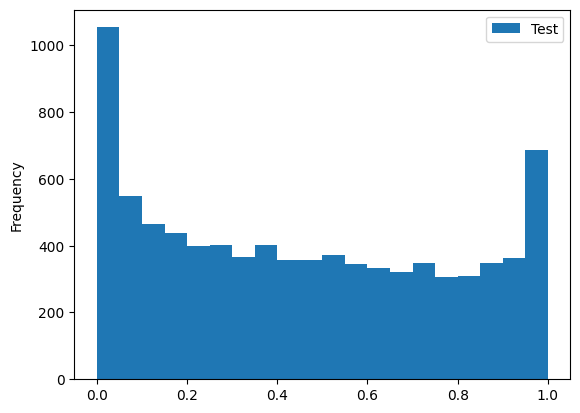

In [22]:
# Predict full distributions
val_dist = model_ngb.pred_dist(X_val)
test_dist = model_ngb.pred_dist(X_test)

# CRPS
# Since the model was trained with Score=CRPScore,
# model.score returns the average CRPS.
val_crps = model_ngb.score(X_val, y_val)
test_crps = model_ngb.score(X_test, y_test)

test_pit = test_dist.cdf(y_test.values)

# Plotting test PIT histogram
pd.Series(test_pit).plot(
    kind="hist",
    bins=20,
    legend=True,
    label="Test"
)


scores = pd.DataFrame({
    "CRPS": [val_crps, test_crps],
    "PIT mean": [None, test_pit.mean()],
    "PIT variability": [None, test_pit.var()]
}, index=["Validation", "Test"]).T


scores

In [35]:
# Defining the thresholds for the cummulative distribution function
thresholds = list(range(0, 111, 1))

# Repeating the each row with len thresholds
df_training = repeat_df_static(df_main, thresholds)


X = df_training.drop(['obs', 'target'], axis = 1)
y = df_training.target

# Splitting data 60% train 20% validation 20% test
train_size, test_size = train_test_split(df_training.index.unique(), shuffle = False, train_size = 0.6)
val_size, test_size = train_test_split(test_size, shuffle = False, train_size = 0.5)


X_train, y_train = X.loc[train_size], y.loc[train_size]
X_val, y_val = X.loc[val_size], y.loc[val_size]
X_test, y_test = X.loc[test_size], y.loc[test_size]



# Creating a PIT variant of the test subset containing rows from the not repeated df and y values set as the thresholds to directly predict PIT.
X_test_pit = df_main.loc[test_size].rename({'obs': 'threshold'}, axis = 1)
X_test_pit = X_test_pit[X_test.columns]



## Model Selection

### Logistic Regression

In [25]:
# Optimizing logistic regression by CRPS
def objective(trial):
    penalty = trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet'])

    params = {
        'loss': 'log_loss',
        'alpha': trial.suggest_float('alpha', 1e-8, 1e-3, log=True),
        'max_iter': trial.suggest_int('max_iter', 1000, 3000),
        'tol': trial.suggest_float('tol', 1e-5, 1e-2, log=True),
        'average': trial.suggest_categorical('average', [False, True]),
        'class_weight': {1: trial.suggest_float('class_weight', 0.5, 0.9)},
        'random_state': 42,
        'n_jobs': -1,
    }



    # SGD is alot faster tor train when there is million of rows.
    model = make_pipeline(
        StandardScaler(),
        SGDClassifier(**params)
    )

    model.fit(X_train.values, y_train.values)


    # Using the repeated validation data to predict the CDF and reshaping it to be one CDF per forecasting case.
    val_cdf = model.predict_proba(X_val)[:, 1].reshape(-1, len(thresholds))

    # Ensuring that each CDF is monotone.
    val_cdf_monotone = np.maximum.accumulate(val_cdf, axis=1).ravel()

    # Minimizing CRPS
    crps = calculate_crps(val_cdf_monotone, thresholds, y_val)

    return crps

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

[I 2026-05-01 15:43:15,592] A new study created in memory with name: no-name-9d8370b5-af6d-4c15-98a4-b9990d82c00d
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
[I 2026-05-01 15:44:23,880] Trial 0 finished with value: 1.275500437490263 and parameters: {'penalty': 'elasticnet', 'alpha': 2.017644457011104e-07, 'max_iter': 1882, 'tol': 3.527578070133825e-05, 'average': True, 'class_weight': 0.5177014111884274}. Best is trial 0 with value: 1.275500437490263.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
[I 2026-05-01 15:44:54,906] Trial 1 finished with value: 1.1586289342221743 and parameters: {'penalty': 'l2', 'alpha': 7.31403810413913e-07, 'max_iter': 2801, 'tol': 8.35420239027362e-05, 'average': True, 'class_weight': 0.82805266127

,Validation,Test
CRPS,1.281700,1.331595
Brier Score,0.011547,0.011996
PIT mean,NaN,0.447787
PIT variability,NaN,0.148997


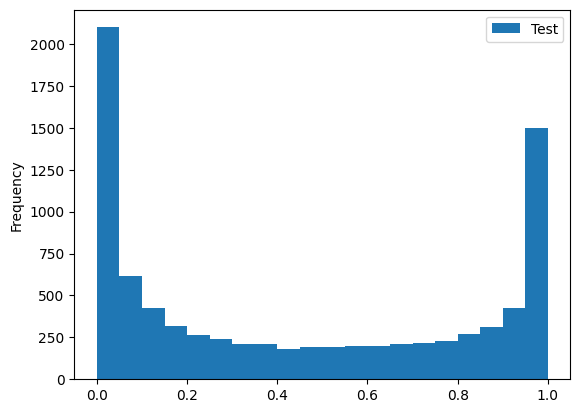

In [36]:
# Refitting the logistic regression using the parameters from the optuna study above

best_params = {'penalty': 'l2', 'alpha': 2.0408278026229763e-07, 'max_iter': 1360, 'tol': 0.0001689442194195867, 'average': True, 'class_weight': 0.6748977913310098}
#best_params = study.best_params

# Class weight has to be a dictionary
class_weight = best_params.pop('class_weight')


model = make_pipeline(
    StandardScaler(),
    SGDClassifier(loss = 'log_loss', **best_params, class_weight = {1: class_weight})
)


model.fit(X_train, y_train)


val_cdf = model.predict_proba(X_val)[:,1]
test_cdf = model.predict_proba(X_test)[:,1]

test_pit = model.predict_proba(X_test_pit)[:,1]


# Plotting validation and test PIT histograms
pd.Series(test_pit).plot(kind = 'hist', bins = 20, legend = True, label = 'Test')




scores = pd.DataFrame({
    'CRPS': [calculate_crps(val_cdf, thresholds, y_val), calculate_crps(test_cdf, thresholds, y_test)],
    'Brier Score': [brier_score_loss(y_val.values, val_cdf), brier_score_loss(y_test.values, test_cdf)],
    'PIT mean': [None, test_pit.mean()],
    'PIT variability': [None, test_pit.var()]
    


}, index = ['Validation', 'Test']).T

scores

### XGBoost

In [41]:
# Optimizing XGBoost by CRPS

def objective(trial):
    params = {
        'device': 'cuda',
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.60, 0.90),
        'n_estimators': trial.suggest_int('n_estimators', 200, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 1, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 500, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 50.0, log=True),
        'monotone_constraints': {'threshold': 1},
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1,
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)

    val_cdf = model.predict_proba(X_val)[:, 1]

    # Monotonocity is already enforced by the monotone constraint argument in the XGBoost model.
    crps = calculate_crps(val_cdf, thresholds, y_val)

    return crps


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print('Best CRPS:', study.best_value)
print('Best params:', study.best_params)

[I 2026-05-01 16:27:19,333] A new study created in memory with name: no-name-e5cb05de-43f7-4055-93b3-1899b8f534ae
[I 2026-05-01 16:27:28,408] Trial 0 finished with value: 10.279003131780007 and parameters: {'scale_pos_weight': 0.6343337489455134, 'n_estimators': 486, 'max_depth': 5, 'learning_rate': 0.001797943559362172, 'subsample': 0.992492126425767, 'colsample_bytree': 0.8556636441555703, 'min_child_weight': 12.216638868766392, 'reg_alpha': 0.38105587201457686, 'reg_lambda': 0.0002745614523867702}. Best is trial 0 with value: 10.279003131780007.
[I 2026-05-01 16:27:46,582] Trial 1 finished with value: 2.581087521240466 and parameters: {'scale_pos_weight': 0.8785522511708481, 'n_estimators': 475, 'max_depth': 11, 'learning_rate': 0.00827220935063628, 'subsample': 0.9935471507959852, 'colsample_bytree': 0.6863940051735596, 'min_child_weight': 15.224307127471487, 'reg_alpha': 2.135374246444453e-05, 'reg_lambda': 0.010704297551118477}. Best is trial 1 with value: 2.581087521240466.
[I 2

Best CRPS: 1.0718385545599785
Best params: {'scale_pos_weight': 0.6051101345236617, 'n_estimators': 316, 'max_depth': 7, 'learning_rate': 0.1744201353555702, 'subsample': 0.6236149356356151, 'colsample_bytree': 0.909387267342235, 'min_child_weight': 4.820221152076625, 'reg_alpha': 2.9200146297377203, 'reg_lambda': 1.0180214304303399e-08}


,Validation,Test
CRPS,1.078437,1.143240
Brier Score,0.009716,0.010299
PIT mean,NaN,0.498913
PIT variability,NaN,0.103842


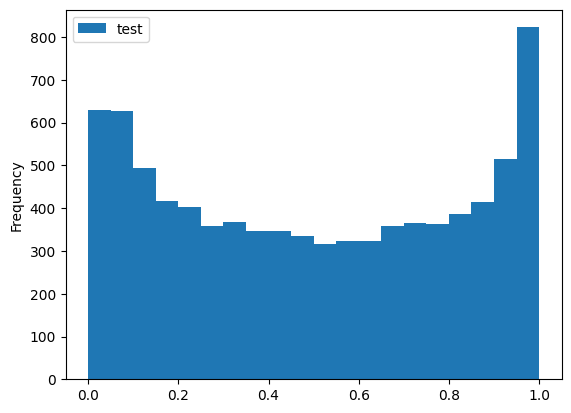

In [47]:
#best_params = study.best_params
best_params = {'scale_pos_weight': 0.6051101345236617, 'n_estimators': 316, 'max_depth': 7, 'learning_rate': 0.1744201353555702, 'subsample': 0.6236149356356151, 'colsample_bytree': 0.909387267342235, 'min_child_weight': 4.820221152076625, 'reg_alpha': 2.9200146297377203, 'reg_lambda': 1.0180214304303399e-08}
monotone_constraints = {
    "threshold": 1
}

model = xgb.XGBClassifier(**best_params, device = 'cuda',  monotone_constraints= monotone_constraints)
#model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))
model.fit(X_train, y_train)

test_cdf = model.predict_proba(X_test)[:,1]
val_cdf = model.predict_proba(X_val)[:,1]

test_pit = model.predict_proba(X_test_pit)[:,1]




scores = pd.DataFrame({
    'CRPS': [calculate_crps(val_cdf, thresholds, y_val), calculate_crps(test_cdf, thresholds, y_test)],
    'Brier Score': [brier_score_loss(y_val.values, val_cdf), brier_score_loss(y_test.values, test_cdf)],
    'PIT mean': [None,test_pit.mean()],
    'PIT variability': [None, test_pit.var()]
    


}, index = ['Validation', 'Test']).T

pd.Series(test_pit).plot(kind = 'hist', bins = 20, legend = True, label = 'test')
scores

## Keras (Work in progress)

In [ ]:

def objective(trial):
    keras.backend.clear_session()
    keras.utils.set_random_seed(42)


    units = trial.suggest_int("units", 16, 128)
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    batch_size = 4096 #trial.suggest_categorical("batch_size", [1024, 2048, 4096, 8192])
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.02)


    normalizer = keras.layers.Normalization()
    normalizer.adapt(X_train.values)


    model = keras.Sequential([
        normalizer,
        keras.layers.Dense(units, activation="relu"),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=weight_decay
        ),
        loss=keras.losses.BinaryCrossentropy(
            label_smoothing=label_smoothing
        ),
        metrics=["mse"]
    )

    callback = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    model.fit(
        X_train.values,
        y_train.values,
        validation_data=(X_val.values, y_val.values),
        epochs=30,
        batch_size=batch_size,
        callbacks=[callback],
        verbose=0
    )

    val_cdf = model.predict(X_val.values, verbose=0).ravel().reshape(-1, len(thresholds))

    val_cdf_monotone = np.maximum.accumulate(val_cdf, axis=1).ravel()

    crps = calculate_crps(val_cdf, thresholds, y_val)

    trial.set_user_attr("crps", crps)
    return crps


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best CRPS:", study.best_value)
print("Best params:", study.best_params)

In [ ]:

keras.backend.clear_session()
keras.utils.set_random_seed(42)



normalizer = keras.layers.Normalization()
normalizer.adapt(X_train.values)



model = keras.Sequential([
    normalizer,
    keras.layers.Dense(1024, activation="relu", kernel_regularizer = keras.regularizers.L2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1024, activation="relu",),#  kernel_regularizer = keras.regularizers.L2(0.0001)),
    keras.layers.Dropout(0.3),
    #keras.layers.Dense(1024, activation="relu"),
    #keras.layers.Dropout(0.3),
    
    
    
    keras.layers.Dense(1, activation="sigmoid")
])



model.compile(
    optimizer=keras.optimizers.AdamW(weight_decay = 0.0001, learning_rate = 0.001),
    loss ='mse',# keras.losses.BinaryCrossentropy(label_smoothing = 0.002),
    metrics=["mse"]
)


early_stop = keras.callbacks.EarlyStopping(monitor='val_loss',patience=15, restore_best_weights=True, min_delta = 0.0001)


reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,         
    patience=3,         
    min_delta=0.0001,      
    verbose=1
)
# Fitting the model.
history = model.fit(
    X_train.values,
    y_train.values,
    epochs=200,
    batch_size=4096,
    callbacks = [early_stop, reduce_lr],
    validation_data = (X_val, y_val)
)
model.save("model_train_only.keras")


In [ ]:
model = keras.models.load_model("model_train_only.keras")

fig, axes = plt.subplots(1,2, figsize = (12,4))
axes = axes.ravel()


#model.fit(X_train.values[-100:], y_train.values[-100:], epochs = 2, batch_size = 4096, initial_epoch = 1)
val_cdf = model.predict(X_val, batch_size = 4096).ravel()
val_pit = model.predict(X_val_pit, batch_size = 4096).ravel()


test_cdf = model.predict(X_test, batch_size = 4096).ravel()
test_pit = model.predict(X_test_pit, batch_size = 4096).ravel()


pd.Series(val_pit).plot(kind = 'hist', bins = 20, ax = axes[0], legend = True, label = 'Validation')
pd.Series(test_pit).plot(kind = 'hist', bins = 20, ax = axes[1], legend = True, label = 'Test')



scores = pd.DataFrame({
    'CRPS': [calculate_crps(val_cdf, thresholds, y_val), calculate_crps(test_cdf, thresholds, y_test)],
    'Brier Score': [brier_score_loss(y_val.values, val_cdf), brier_score_loss(y_test.values, test_cdf)],
    'PIT mean': [val_pit.mean(), test_pit.mean()],
    'PIT variability': [val_pit.var(), test_pit.var()]
    


}, index = ['Validation', 'Test']).T

scores